In [1]:
import torch
import pandas as pd

import sys
import os
sys.path.append(os.path.abspath("utils"))

import importlib
import superdetector_inversion_utils
importlib.reload(superdetector_inversion_utils)

from general_utils import load_images
from superdetector_inversion_utils import superdetector_inversion_across_percentiles, \
      all_superdetector_inversions_across_percentiles, detect_then_invert_locally_metrics, \
      detect_then_invert_locally_metrics_over_percentiles, detect_then_invert_locally_performance_heatmap, \
      find_all_superdetector_patches

In [2]:
PERCENT_THRU_MODEL = 100
SAMPLE_TYPE = 'patch'
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(DEVICE)

cuda


# Select Model

In [3]:
MODEL_NAME = 'CLIP'
INPUT_IMAGE_SIZE = (224, 224)

In [3]:
MODEL_NAME = 'Llama'
INPUT_IMAGE_SIZE = (560, 560)

# Select Dataset

In [38]:
DATASET_NAME = 'CLEVR'

In [4]:
DATASET_NAME = 'Coco'

# Set Files

In [6]:
#avg 
EMBEDDINGS_FILE = f'{MODEL_NAME}_{SAMPLE_TYPE}_embeddings_percentthrumodel_{PERCENT_THRU_MODEL}.pt'
CONCEPTS_FILE = f'avg_concepts_{EMBEDDINGS_FILE}'
CON_LABEL = f"{MODEL_NAME}_avg_{SAMPLE_TYPE}_embeddings_percentthrumodel_{PERCENT_THRU_MODEL}"
COSSIM_FILE = f'cosine_similarities_{CONCEPTS_FILE[:-3]}.csv'

In [5]:
#linsep
BALANCE_DATA = True
BALANCE_NEGATIVES = True

EMBEDDINGS_FILE = f'{MODEL_NAME}_{SAMPLE_TYPE}_embeddings_percentthrumodel_{PERCENT_THRU_MODEL}.pt'
CONCEPTS_FILE = f'linsep_concepts_BD_{BALANCE_DATA}_BN_{BALANCE_NEGATIVES}_{EMBEDDINGS_FILE}'
CON_LABEL = f"{MODEL_NAME}_linsep_{SAMPLE_TYPE}_embeddings_BD_{BALANCE_DATA}_BN_{BALANCE_NEGATIVES}_percentthrumodel_{PERCENT_THRU_MODEL}"
DISTS_FILE = f'dists_{CONCEPTS_FILE[:-3]}.csv'

# Load Data you Need

In [ ]:
# from tqdm import tqdm
# high_freq_concepts = ['accessory', 'animal', 'appliance', 'bench', 'book', 'bottle', 'bowl', 'bus', 'car', 
#                           'chair', 'couch', 'cup', 'dining table', 'electronic', 'food', 'furniture', 'indoor', 
#                           'kitchen', 'motorcycle', 'outdoor', 'person', 'pizza', 'potted plant', 'sports', 
#                           'train', 'truck', 'tv', 'umbrella', 'vehicle']

# for f in tqdm(os.listdir(f'Distances/Coco')):
#     if 'avg' in f or 'linsep' in f:
#         df = pd.read_csv(f'Distances/Coco/{f}')
#         new_df = df[high_freq_concepts]
#         new_df.to_csv(f'Distances/Coco/{f}')
#         # print(new_df.columns)
#     # try:
#     #     # dic = torch.load(f'GT_Samples/Coco/{f}')
#     #     # new_dic = {k:v for k,v in dic.items() if k in high_freq_concept}
#     #     # torch.save(new_dic, f'GT_Samples/Coco/{f}')
#     #     # print(dic.keys())
#     # except:
#     #     continue

 87%|████████▋ | 13/15 [12:58<00:49, 24.53s/it]

In [7]:
gt_patches_per_concept = torch.load(f'GT_Samples/{DATASET_NAME}/gt_patches_per_concept_inputsize_{INPUT_IMAGE_SIZE}.pt')
gt_patches_per_concept_train = torch.load(f'GT_Samples/{DATASET_NAME}/gt_patch_per_concept_train_inputsize_{INPUT_IMAGE_SIZE}.pt')
gt_patches_per_concept_test = torch.load(f'GT_Samples/{DATASET_NAME}/gt_patch_per_concept_test_inputsize_{INPUT_IMAGE_SIZE}.pt')

gt_samples_per_concept = torch.load(f'GT_Samples/{DATASET_NAME}/gt_samples_per_concept_inputsize_{INPUT_IMAGE_SIZE}.pt')
gt_samples_per_concept_train = torch.load(f'GT_Samples/{DATASET_NAME}/gt_samples_per_concept_train_inputsize_{INPUT_IMAGE_SIZE}.pt')
gt_samples_per_concept_test = torch.load(f'GT_Samples/{DATASET_NAME}/gt_samples_per_concept_test_inputsize_{INPUT_IMAGE_SIZE}.pt')

In [8]:
concepts = torch.load(f'Concepts/{DATASET_NAME}/{CONCEPTS_FILE}')

if 'avg' in CON_LABEL:
    sim_metrics = pd.read_csv(f"Cosine_Similarities/{DATASET_NAME}/{COSSIM_FILE}")
elif 'linsep' in CON_LABEL:
    sim_metrics = pd.read_csv(f"Distances/{DATASET_NAME}/{DISTS_FILE}")    
    
if DATASET_NAME == 'Coco':
    curr_concepts = ['animal', 'person', 'vehicle', 'horse', 'outdoor']
    gt_patches_per_concept_test_filtered = {k:v for k, v in gt_patches_per_concept_test.items() if k in curr_concepts}
    gt_samples_per_concept_test_filtered = {k:v for k, v in gt_samples_per_concept_test.items() if k in curr_concepts}
    start_idx=10
else:
    curr_concepts = concepts.keys()
    gt_patches_per_concept_test_filtered = gt_patches_per_concept_test
    gt_samples_per_concept_test_filtered = gt_samples_per_concept_test
    start_idx=4

In [ ]:
all_images, train_images, test_images = load_images(dataset_name=DATASET_NAME)

#might need to change if something isn't computed yet
embeds_dic = torch.load(f"Embeddings/{DATASET_NAME}/{EMBEDDINGS_FILE}")
embeds = embeds_dic['normalized_embeddings']

# Inversion Based on Superdetection

In [ ]:
percentiles = [0.01, 0.02, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 1.0]
inversions_df = all_superdetector_inversions_across_percentiles(percentiles, 'avg', embeds, sim_metrics,
                                   gt_patches_per_concept_test, DATASET_NAME, INPUT_IMAGE_SIZE, CON_LABEL, 
                                                DEVICE, patch_size=14, local=True)

 57%|█████▋    | 8/14 [1:52:10<1:36:30, 965.04s/it]

# Get Quantitative Results

In [9]:
# percentiles = [0.01, 0.02, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 1.0]
percentiles = [0.02, 0.1, 0.2, 0.4, 0.6, 0.8, 0.95]

detect_then_invert_locally_metrics_over_percentiles(percentiles, percentiles, sim_metrics, 
                                                        concepts, gt_patches_per_concept, gt_patches_per_concept_test,
                                                        DEVICE, DATASET_NAME, INPUT_IMAGE_SIZE, CON_LABEL,
                                                        all_object_patches=None, patch_size=14)

Evaluating thresholds:   0%|          | 0/21 [00:00<?, ?it/s]

FileNotFoundError: [Errno 2] No such file or directory: 'Superpatches/Coco/superpatch_avg_inv_per_0.02_Llama_avg_patch_embeddings_percentthrumodel_100.csv'

In [ ]:
percentiles = [0.02, 0.1, 0.2, 0.4, 0.6, 0.8, 0.95]
detect_then_invert_locally_performance_heatmap('f1', gt_patches_per_concept_test, DATASET_NAME, CON_LABEL, 
                                        detect_percentiles=percentiles, invert_percentiles=percentiles, 
                                               agglomerate_type='avg', just_obj=False)

# Visualization

## Regular heatmap

/shared_data0/cgoldberg/Concept_Inversion/Experiments/utils/visualize_concepts_w_samples_utils.py:570: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # Leave space for the color bar


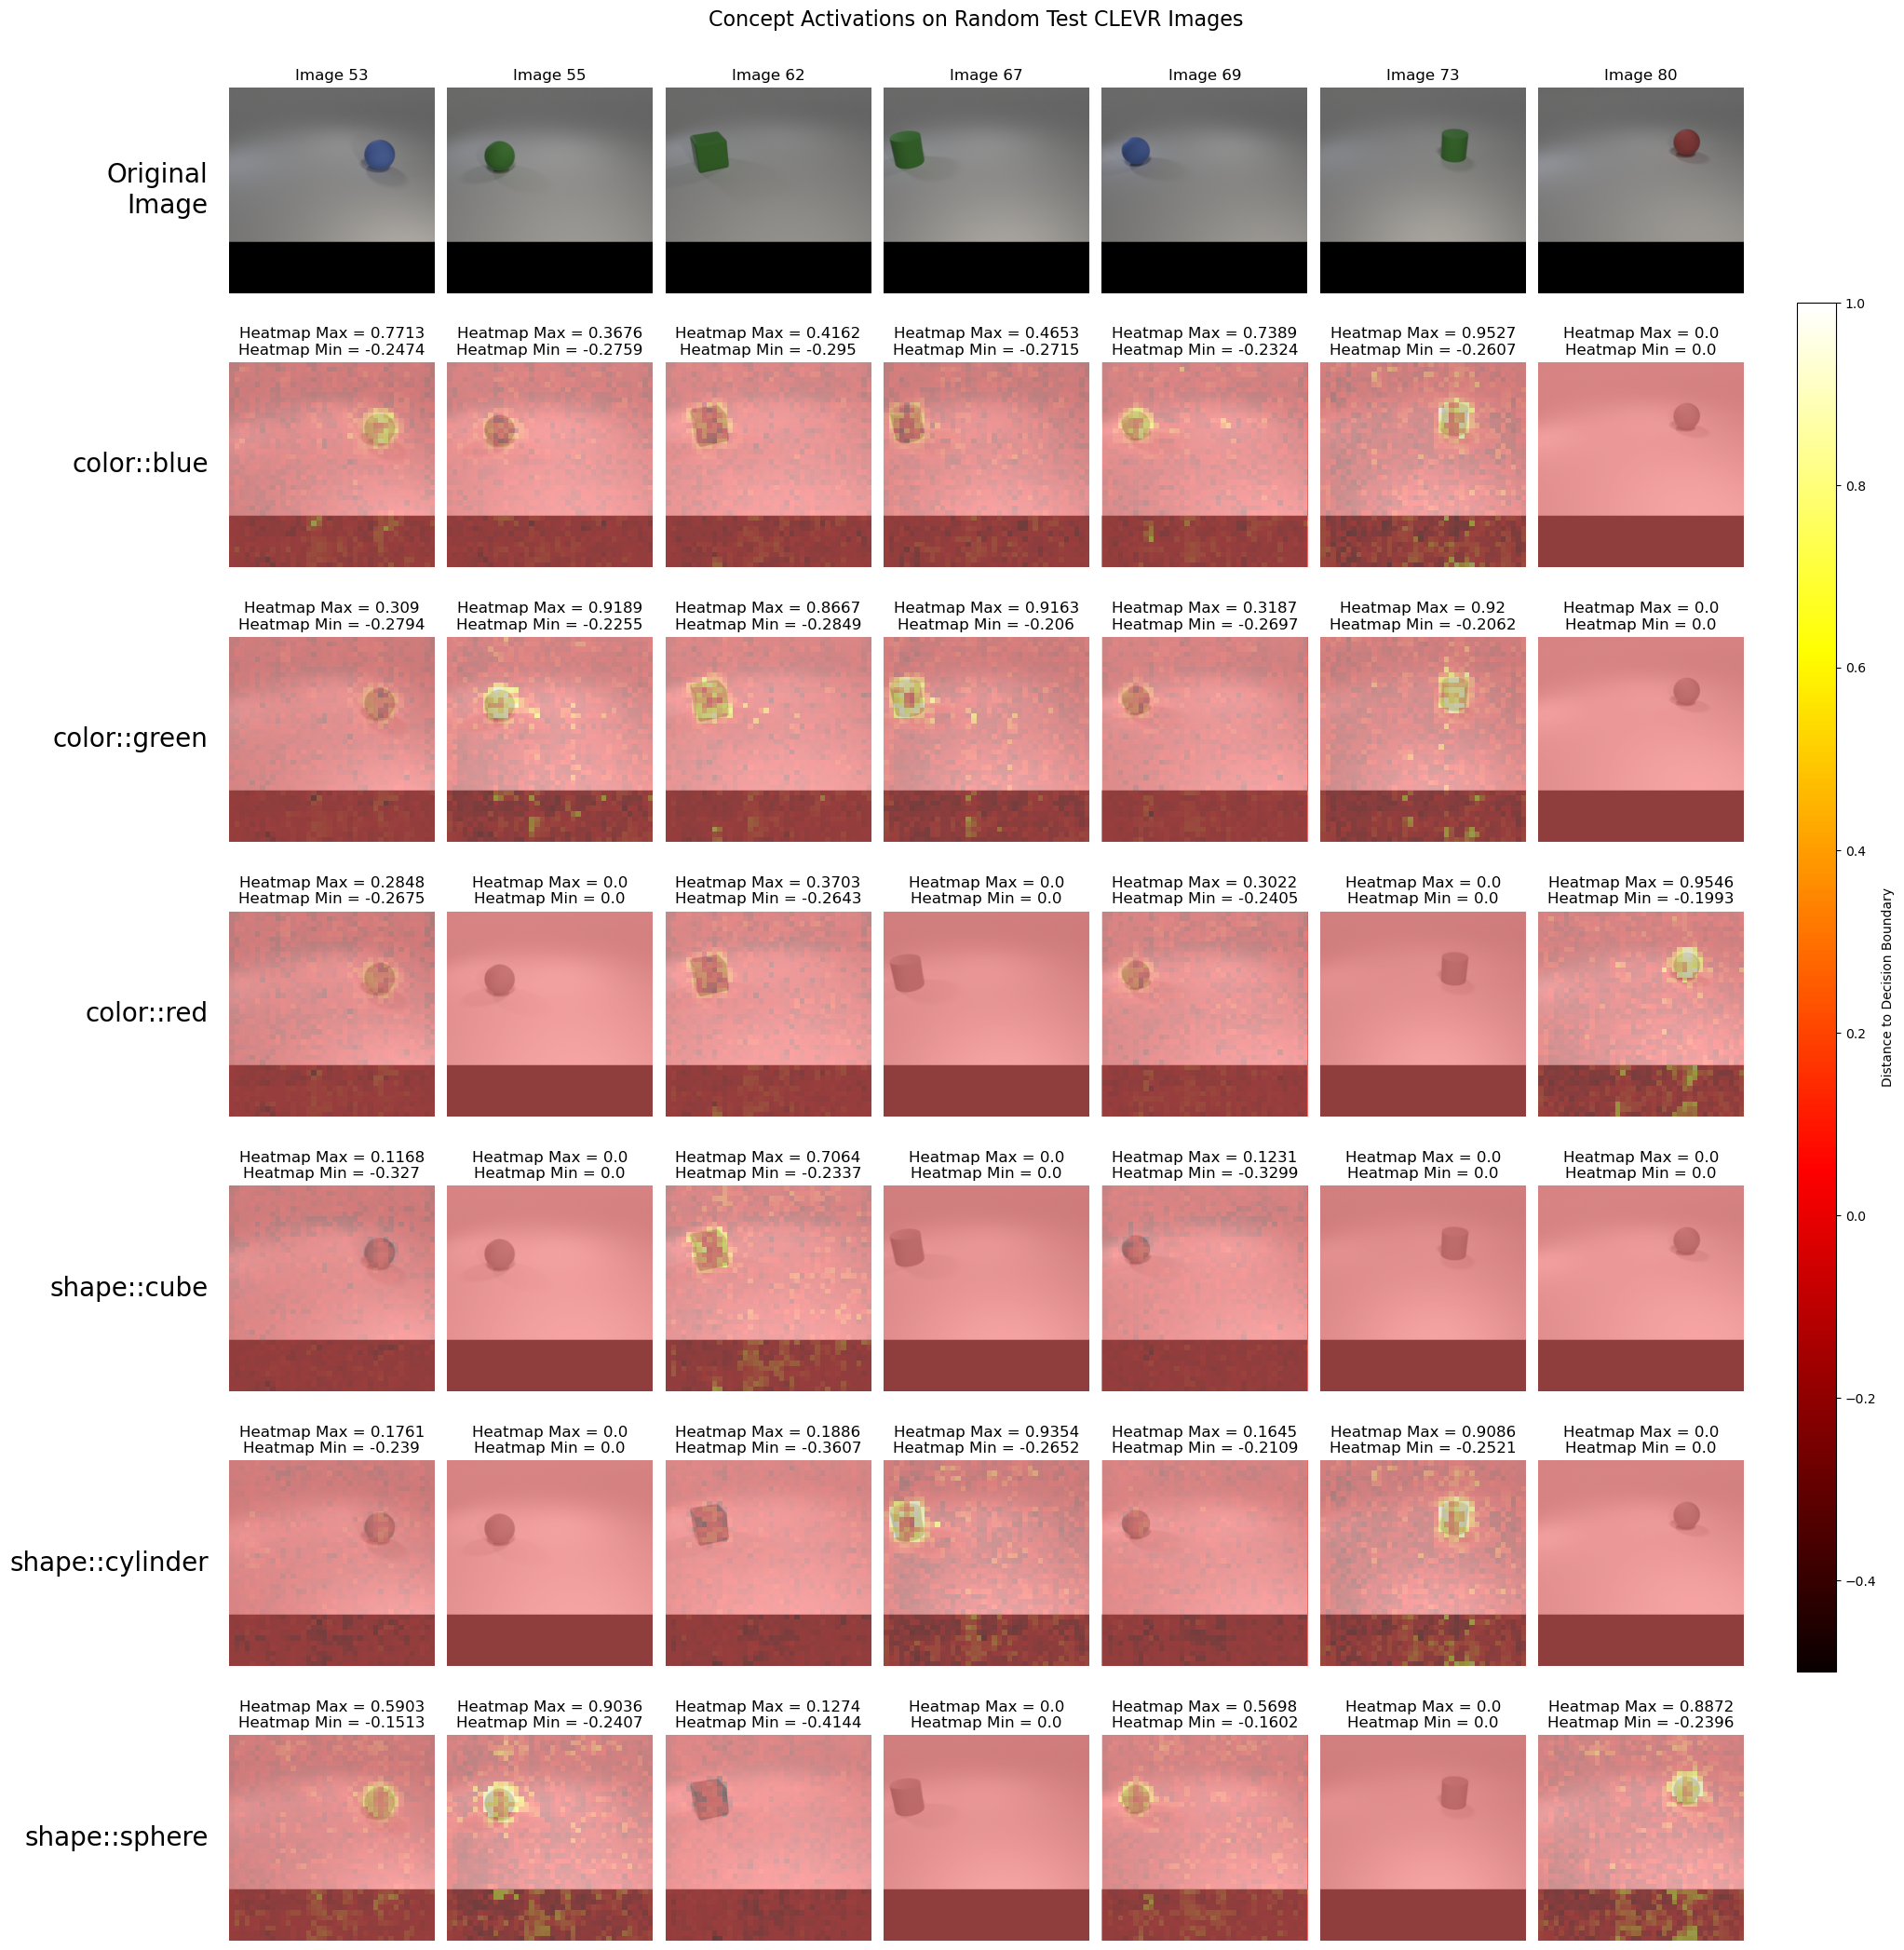

In [295]:
from general_utils import retrieve_topn_samples
from patch_alignment_utils import compute_heatmaps_for_concept
from visualize_concepts_w_samples_utils import plot_patchsims_heatmaps_all_concepts

invert_percentile = 0.4
inversion_acts = pd.read_csv(f'Superpatches/{DATASET_NAME}/superpatch_inv_per_{invert_percentile}_{CON_LABEL}.csv')
top_n = 7
image_indices = retrieve_topn_samples(DATASET_NAME, top_n, start_idx=10, split='test')

all_concept_heatmaps = {}
for concept_label in concepts.keys():
    heatmaps = compute_heatmaps_for_concept(concept_label, image_indices, all_images, embeds,
                                            inversion_acts, DATASET_NAME, CON_LABEL, top_n=top_n, 
                                            model_input_size=INPUT_IMAGE_SIZE,)
    
    # plot_patchsims_for_concept(concept_label, heatmaps=heatmaps, image_indices=image_indices, images=all_images,
    #                            dataset_name=DATASET_NAME, top_n=top_n,
    #                            model_input_size=INPUT_IMAGE_SIZE, vmin=-0.5, vmax=0.5)
    all_concept_heatmaps[concept_label] = heatmaps
    
plot_patchsims_heatmaps_all_concepts(curr_concepts, heatmaps=all_concept_heatmaps, image_indices=image_indices,
                           images=all_images, dataset_name=DATASET_NAME, model_input_size=INPUT_IMAGE_SIZE,
                           top_n=top_n, metric_type = 'Distance to Decision Boundary', vmin=-0.5, vmax=1)

# Heatmaps over percentiles

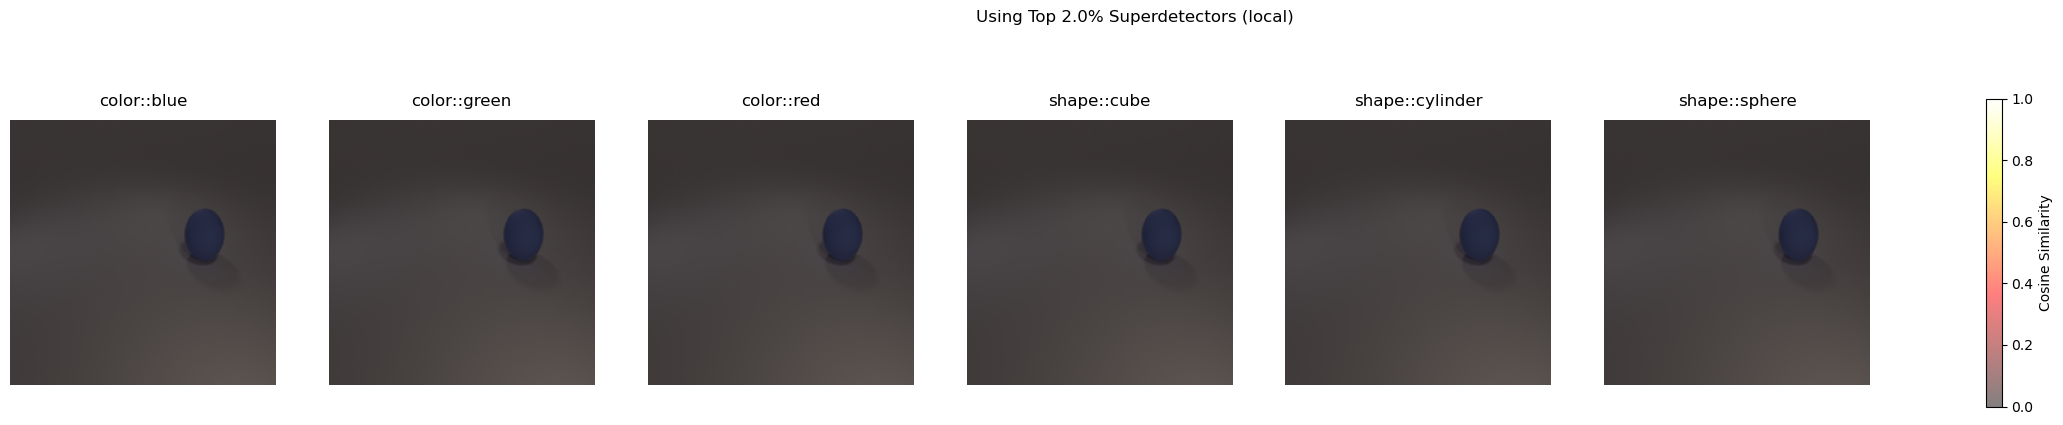

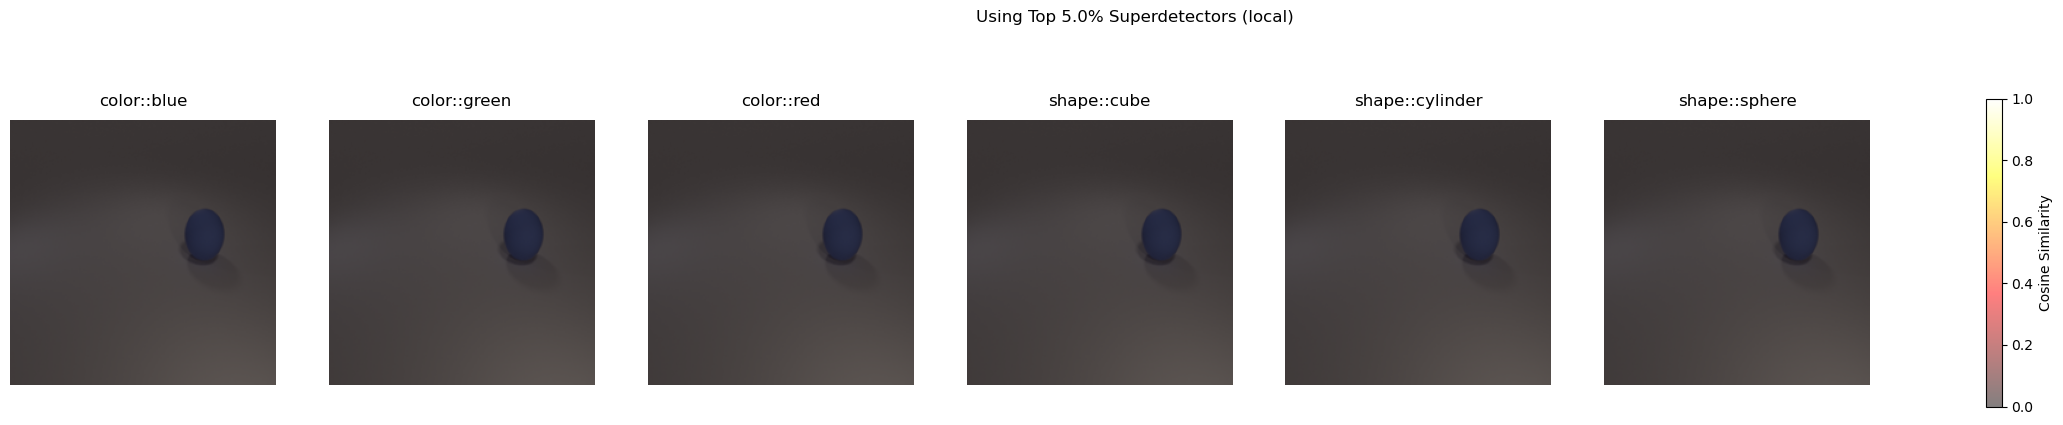

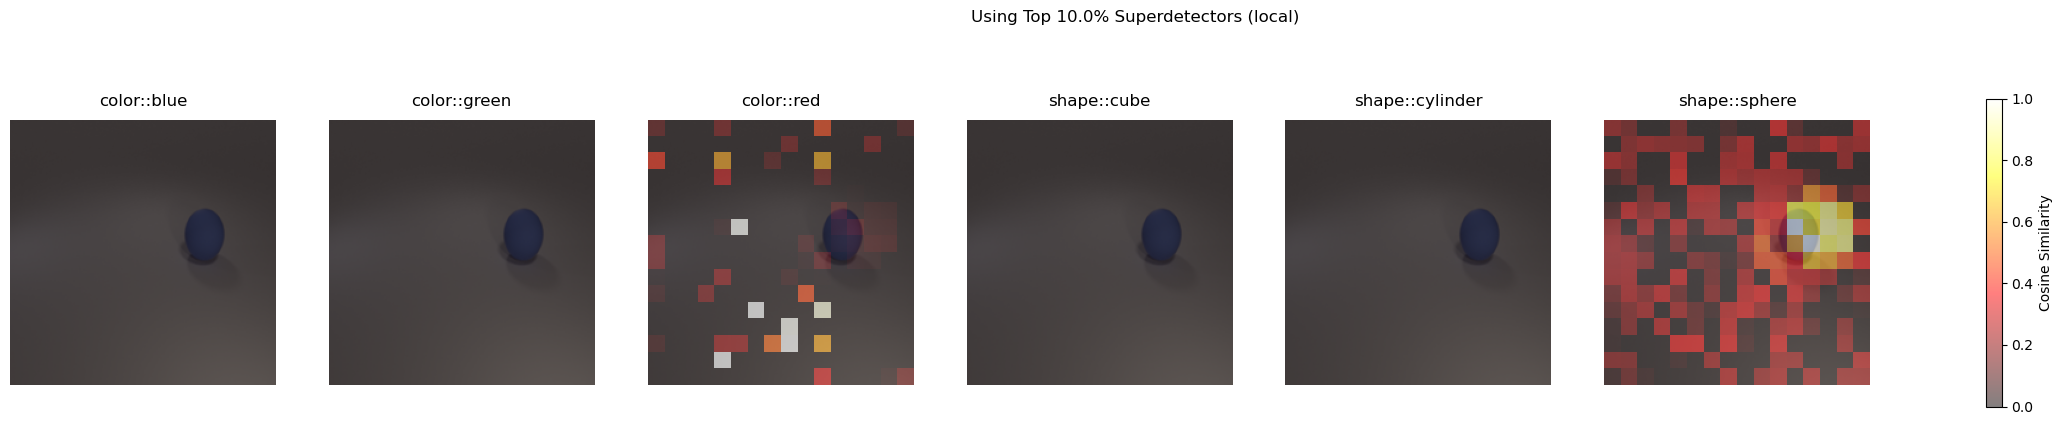

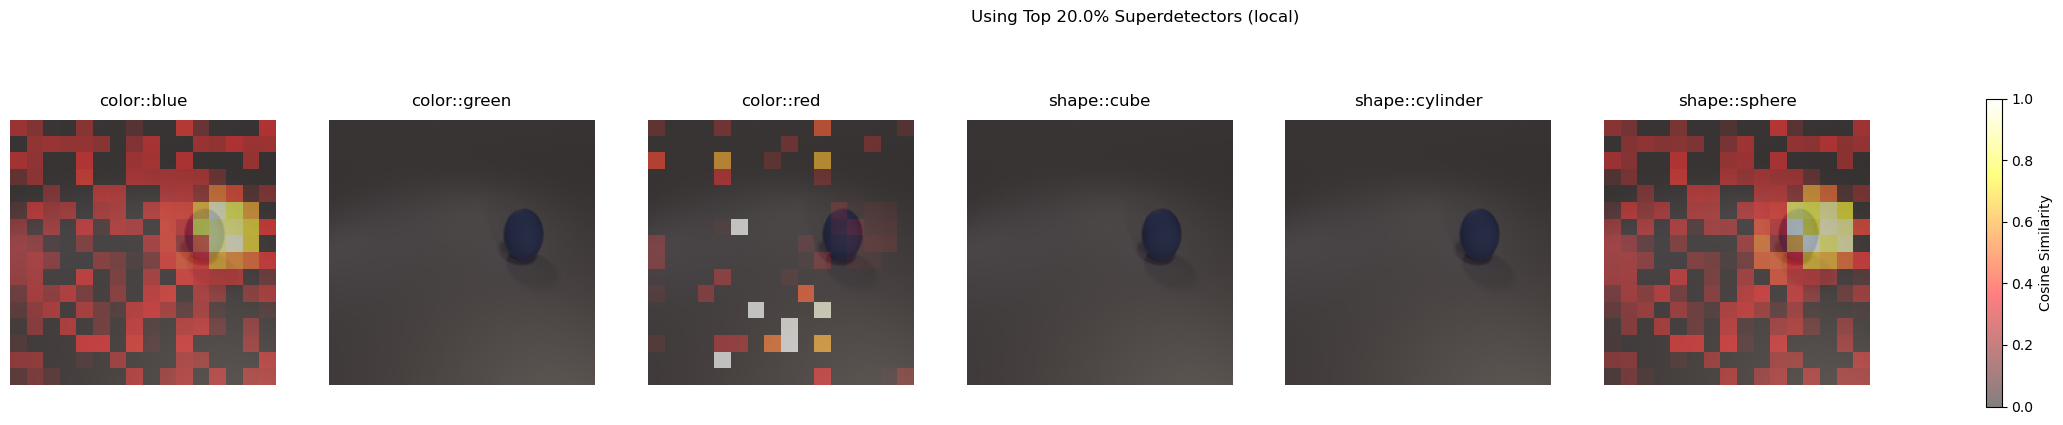

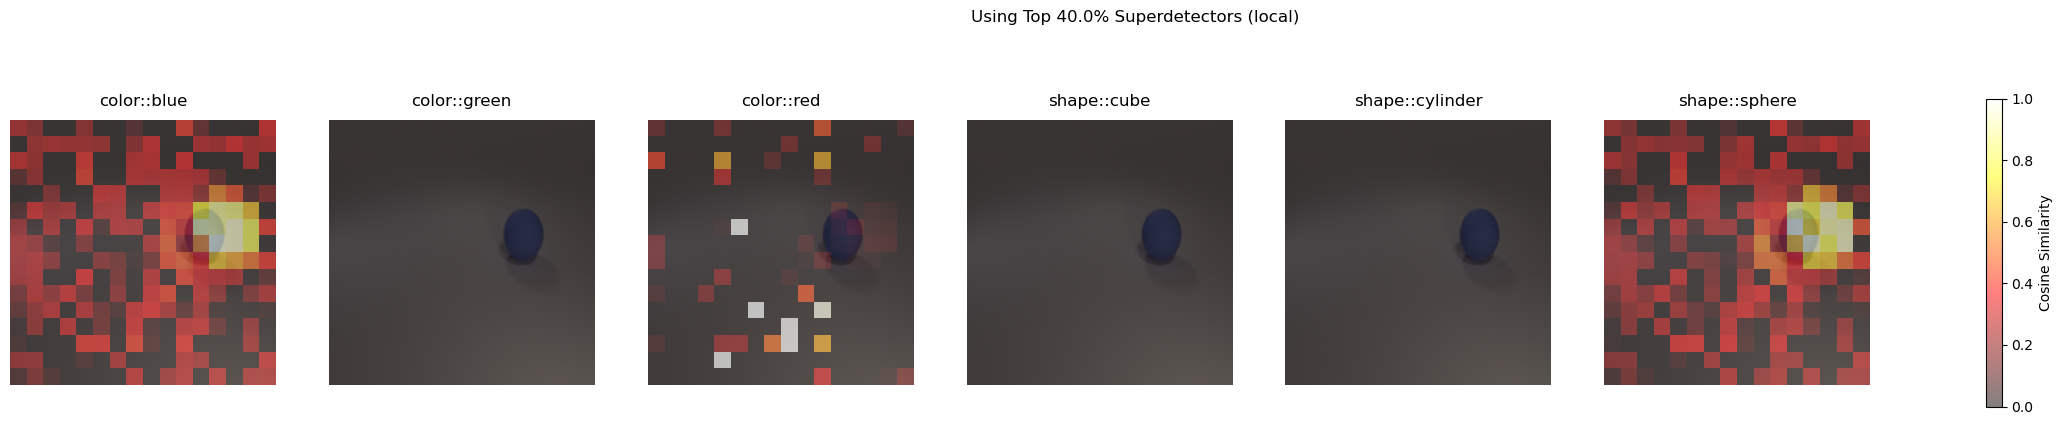

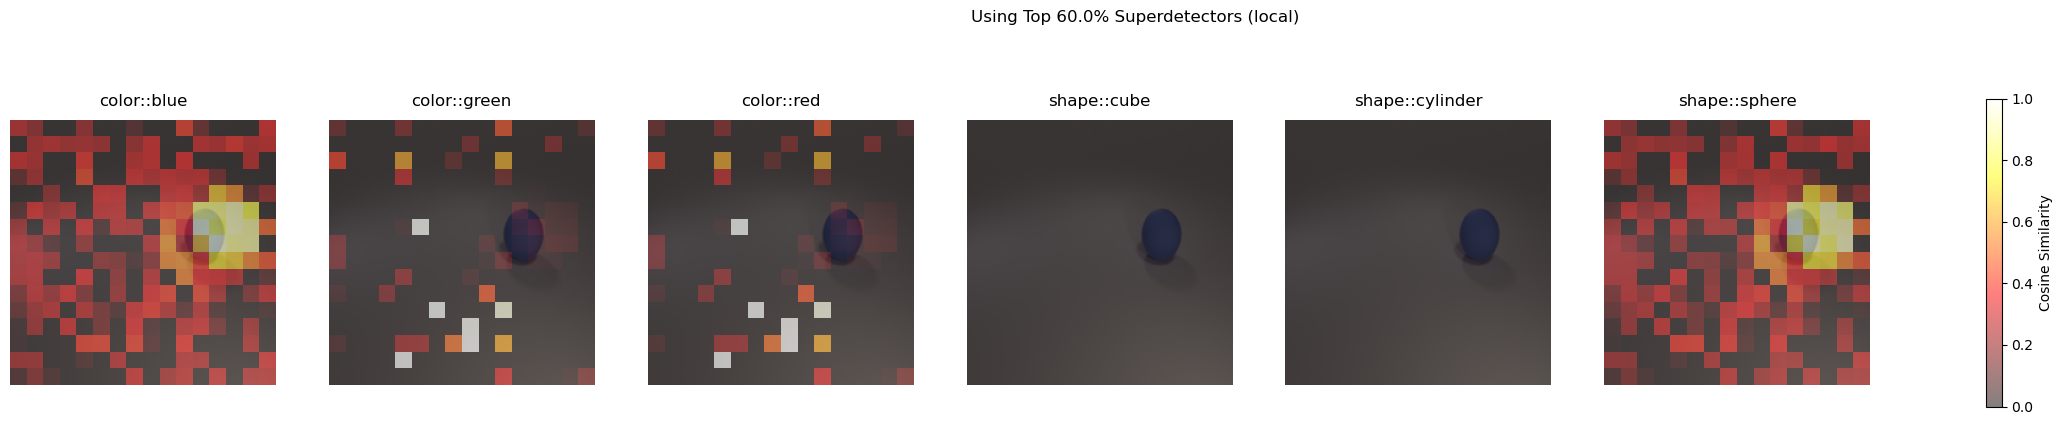

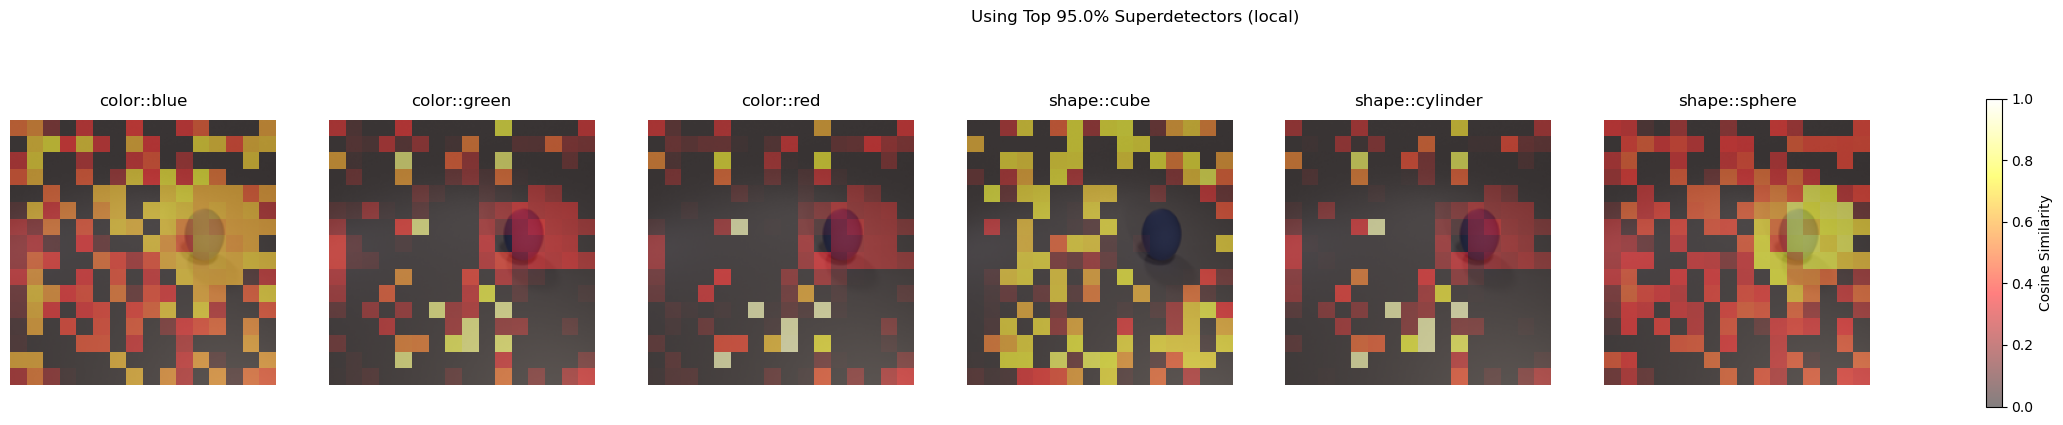

In [31]:
aggolmerate_type = 'avg'
percentiles = [0.02, 0.05, 0.1, 0.2, 0.4, 0.6, 0.95]
img_idx = 53

inversions_per_percentile = superdetector_inversion_across_percentiles(percentiles, img_idx, 
                                                                       all_images, aggolmerate_type, embeds, 
                                                              sim_metrics, gt_samples_per_concept_test, 
                                  DATASET_NAME, INPUT_IMAGE_SIZE, CON_LABEL, DEVICE, do_plot=True, local=True)

# Calculate All Superpatches

In [ ]:
high_freq_concepts = ['accessory', 'animal', 'appliance', 'bench', 'book', 'bottle', 'bowl', 'bus', 'car', 
                          'chair', 'couch', 'cup', 'dining table', 'electronic', 'food', 'furniture', 'indoor', 
                          'kitchen', 'motorcycle', 'outdoor', 'person', 'pizza', 'potted plant', 'sports', 
                          'train', 'truck', 'tv', 'umbrella', 'vehicle']

dict_keys(['accessory', 'animal', 'appliance', 'backpack', 'bed', 'bench', 'bicycle', 'book', 'bottle', 'bowl', 'bus', 'car', 'cat', 'cell phone', 'chair', 'clock', 'couch', 'cup', 'dining table', 'dog', 'electronic', 'food', 'fork', 'furniture', 'handbag', 'indoor', 'kitchen', 'knife', 'laptop', 'motorcycle', 'outdoor', 'person', 'pizza', 'potted plant', 'sink', 'spoon', 'sports', 'sports ball', 'surfboard', 'tennis racket', 'traffic light', 'train', 'truck', 'tv', 'umbrella', 'vehicle'])


In [65]:
from tqdm import tqdm

for percentile in tqdm([0.02, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5]):
    find_all_superdetector_patches(percentile, sim_metrics, gt_samples_per_concept_test, 
                                    DATASET_NAME, INPUT_IMAGE_SIZE, CON_LABEL, DEVICE)

  0%|          | 0/7 [00:00<?, ?it/s]


KeyError: 'airplane'